Input size in inches (default is 13):  30


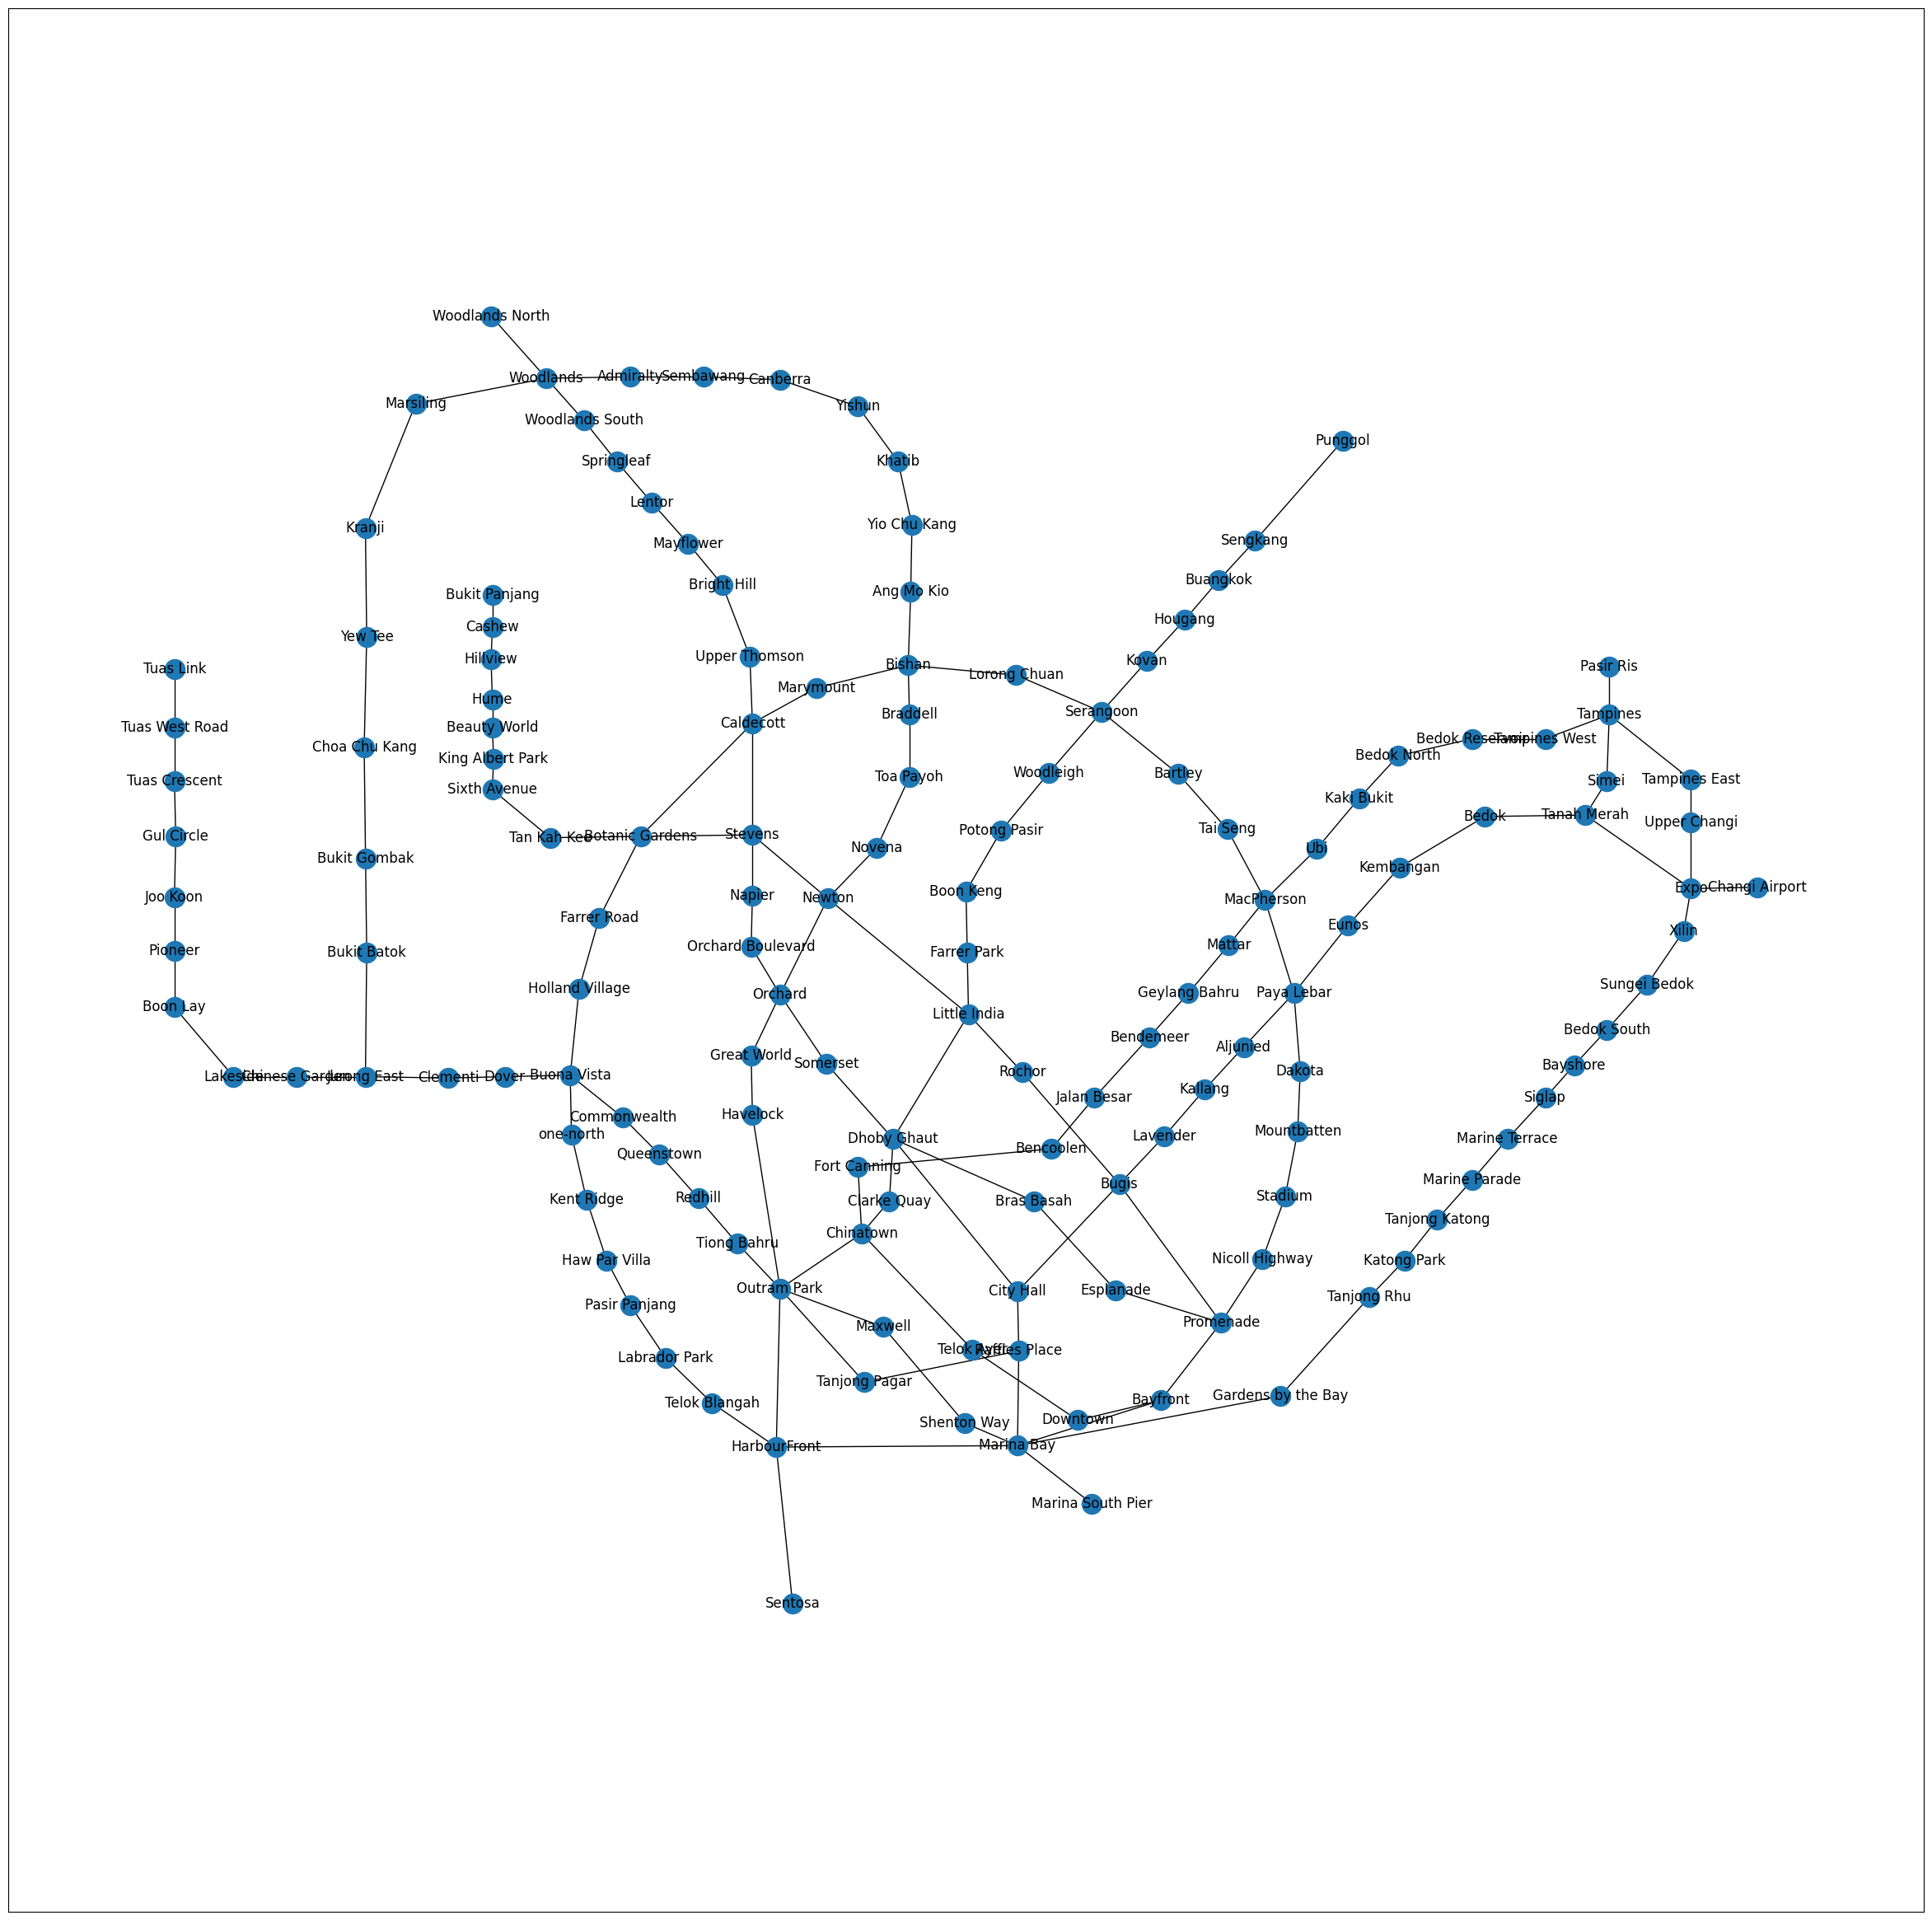

In [9]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SPREAD = 100
user_input = input("Input size in inches (default is 13): ")
FIGSIZE = int(user_input) if user_input.strip() else 13
plt.figure(figsize=(FIGSIZE, FIGSIZE))

stations = pd.read_excel("singapore_stations.xlsx", sheet_name="stations").set_index("id")
connection = pd.read_excel("singapore_stations.xlsx", sheet_name="connections")

def get_station_name(station_id):
    #SELECT station_name FROM stations WHERE id == cur/next
    if pd.isna(station_id):
        return None
    return stations.at[station_id, "station_name"]

graph = nx.Graph()
for row in stations.itertuples():
    graph.add_node(row.station_name, npos=(row.x * SPREAD, row.y * -SPREAD), ccn='#00FF00')

for row in connection.itertuples():
    current = get_station_name(row.cur_station)
    next = get_station_name(row.next_station)
    
    if current is not None:
        if next is not None:
            graph.add_edge(current, next)

pos = nx.get_node_attributes(graph, 'npos')

nx.draw_networkx(graph, pos)

plt.axis('equal')
plt.show()